# Task XI: Embedding Normally Distributed Data Using MLP + Parameterized Quantum Circuit (PQC)
**GSoC 2026 | QMLHEP | Quantum Reinforcement Learning for High Energy Physics**

## Objective
Build a **hybrid classical-quantum model** that:
1. Takes normally distributed input data
2. Passes it through an **MLP** to produce PQC parameters (rotation angles)
3. Feeds those parameters into a **Parameterized Quantum Circuit** to prepare a quantum state
4. Uses quantum **expectation values** (Pauli-Z measurements) as the embedded representation
5. Trains end-to-end via **backpropagation** through both the MLP and PQC

### Architecture
```
Input x ∈ ℝ¹⁰ → MLP → θ ∈ ℝ⁸ (PQC angles) → PQC(θ) → ⟨Z₀Z₁Z₂Z₃⟩ ∈ ℝ⁴ → MSE vs target
```

In [2]:
# Install dependencies
!pip install pennylane torch matplotlib numpy scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.2/57.2 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 33.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 26.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 34.3 MB/s eta 0:00:00


In [3]:
import pennylane as qml
from pennylane import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import matplotlib

matplotlib.rcParams['figure.dpi'] = 120
torch.manual_seed(42)
np.random.seed(42)

torch.set_default_dtype(torch.float32)

print(f'PennyLane: {qml.__version__}')
print(f'PyTorch:   {torch.__version__}')
print(f'Default dtype: {torch.get_default_dtype()}')


PennyLane: 0.44.0
PyTorch:   2.10.0+cpu
Default dtype: torch.float32


---
## 1. Data Generation

We sample 1000 data points from a 10-dimensional standard normal distribution N(0, I₁₀).

In [4]:
N_SAMPLES  = 1000
INPUT_DIM  = 10
N_QUBITS   = 4
N_LAYERS   = 2   # PQC depth
N_PQC_PARAMS = N_QUBITS * N_LAYERS * 2  # RX + RY per qubit per layer = 16

# Generate data: (1000, 10)
data_np = np.random.randn(N_SAMPLES, INPUT_DIM)

data    = torch.tensor(data_np, dtype=torch.float32)
pca = PCA(n_components=N_QUBITS)
target_np = np.tanh(pca.fit_transform(data_np) * 0.5)
target    = torch.tensor(target_np, dtype=torch.float32)

print(f'Data shape:    {data.shape}   dtype={data.dtype}')
print(f'Target shape:  {target.shape}  dtype={target.dtype}')
print(f'Target range:  [{target.min():.3f}, {target.max():.3f}]')
print(f'PQC params per sample: {N_PQC_PARAMS}')

print('\nDtype checklist:')
print(f'  data dtype   : {data.dtype}    <- must be float32')
print(f'  target dtype : {target.dtype}  <- must be float32')


Data shape:    torch.Size([1000, 10])   dtype=torch.float32
Target shape:  torch.Size([1000, 4])  dtype=torch.float32
Target range:  [-0.965, 0.939]
PQC params per sample: 16

Dtype checklist:
  data dtype   : torch.float32    <- must be float32
  target dtype : torch.float32  <- must be float32


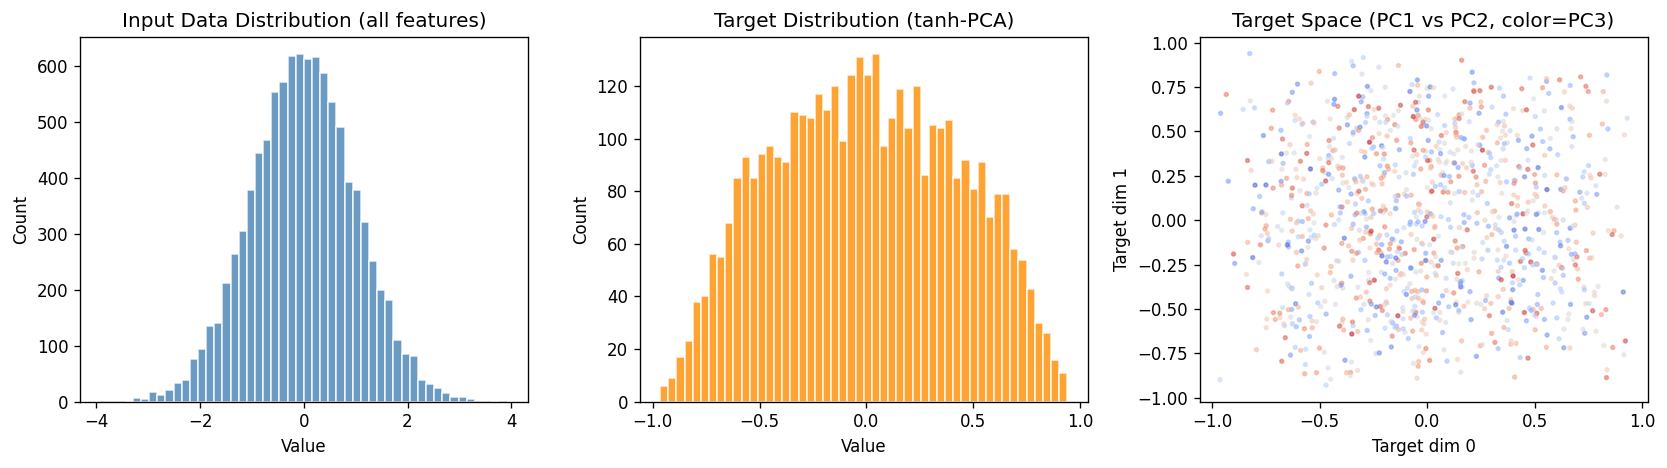

In [5]:
# Visualize data distribution
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(data_np.flatten(), bins=50, color='steelblue', alpha=0.8, edgecolor='white')
axes[0].set_title('Input Data Distribution (all features)')
axes[0].set_xlabel('Value')
axes[0].set_ylabel('Count')

axes[1].hist(target_np.flatten(), bins=50, color='darkorange', alpha=0.8, edgecolor='white')
axes[1].set_title('Target Distribution (tanh-PCA)')
axes[1].set_xlabel('Value')
axes[1].set_ylabel('Count')

axes[2].scatter(target_np[:,0], target_np[:,1], s=5, c=target_np[:,2], cmap='coolwarm', alpha=0.5)
axes[2].set_title('Target Space (PC1 vs PC2, color=PC3)')
axes[2].set_xlabel('Target dim 0')
axes[2].set_ylabel('Target dim 1')

plt.tight_layout()
plt.savefig('data_distribution.png', bbox_inches='tight')
plt.show()

---
## 2. Parameterized Quantum Circuit (PQC)

The PQC has:
- **Encoding layers**: RX(θᵢ) and RY(φᵢ) on each qubit (angle embedding)
- **Entangling layers**: CNOT ring (0→1→2→3→0)
- Repeated for `N_LAYERS` layers

Output: Expectation value ⟨Z⟩ on each qubit → 4D embedding vector in [-1, 1]⁴

/tmp/ipython-input-502/2375715508.py:40: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


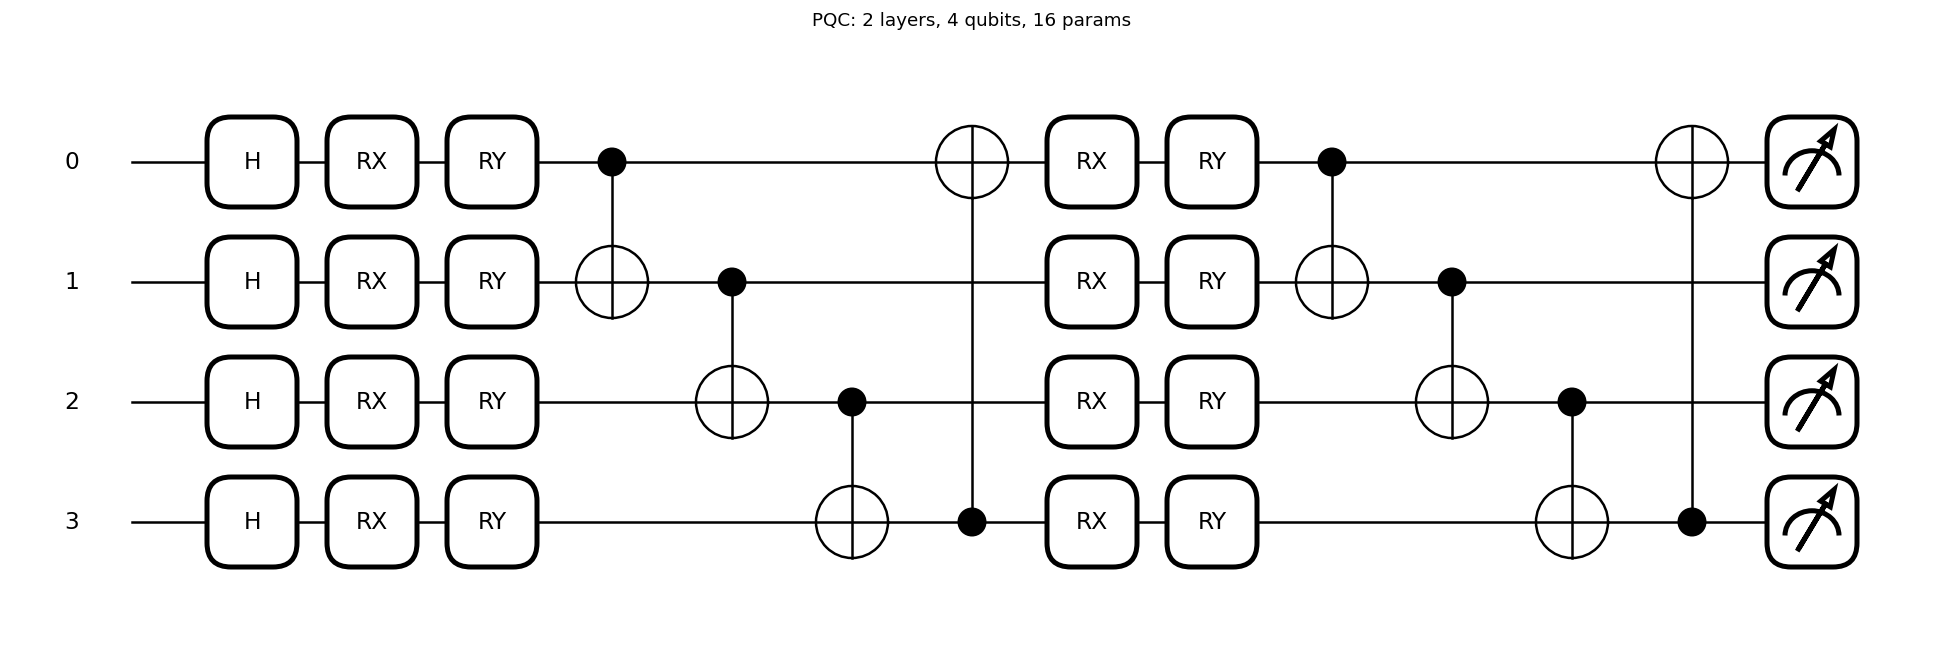

PQC output dtype (raw): torch.float64  ← will be cast to float32 in HybridModel
PQC text diagram:
0: ──H──RX(0.00)──RY(0.00)─╭●───────╭X──RX(0.00)──RY(0.00)─╭●───────╭X─┤  <Z>
1: ──H──RX(0.00)──RY(0.00)─╰X─╭●────│───RX(0.00)──RY(0.00)─╰X─╭●────│──┤  <Z>
2: ──H──RX(0.00)──RY(0.00)────╰X─╭●─│───RX(0.00)──RY(0.00)────╰X─╭●─│──┤  <Z>
3: ──H──RX(0.00)──RY(0.00)───────╰X─╰●──RX(0.00)──RY(0.00)───────╰X─╰●─┤  <Z>


In [6]:
dev = qml.device('default.qubit', wires=N_QUBITS)

@qml.qnode(dev, interface='torch', diff_method='backprop')
def pqc(params):

    for i in range(N_QUBITS):
        qml.Hadamard(wires=i)

    # Variational layers
    idx = 0
    for layer in range(N_LAYERS):
        # Rotation layer
        for i in range(N_QUBITS):
            qml.RX(params[idx],     wires=i)
            qml.RY(params[idx + 1], wires=i)
            idx += 2
        # Entangling layer (CNOT ring)
        for i in range(N_QUBITS):
            qml.CNOT(wires=[i, (i + 1) % N_QUBITS])

    # Measure: ⟨Z⟩ on each qubit
    return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]

# Visualize PQC structure
dummy_params = torch.zeros(N_PQC_PARAMS)
fig, ax = qml.draw_mpl(pqc)(dummy_params)
ax.set_title(f'PQC: {N_LAYERS} layers, {N_QUBITS} qubits, {N_PQC_PARAMS} params', fontsize=11, pad=10)
plt.tight_layout()
plt.savefig('pqc_structure.png', bbox_inches='tight')
plt.show()

# Confirm output dtype from PQC
test_out = pqc(dummy_params)
print(f'PQC output dtype (raw): {test_out[0].dtype}  ← will be cast to float32 in HybridModel')
print(f'PQC text diagram:\n{qml.draw(pqc)(dummy_params)}')


---
## 3. Classical MLP

The MLP maps input x ∈ ℝ¹⁰ → rotation angles θ ∈ ℝ¹⁶ for the PQC.
Uses **tanh** output activation to keep angles in a bounded range.

In [7]:
class MLP(nn.Module):
    def __init__(self, in_dim=INPUT_DIM, out_dim=N_PQC_PARAMS):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 64),
            nn.ELU(),
            nn.Linear(64, 32),
            nn.ELU(),
            nn.Linear(32, out_dim),
            nn.Tanh()
        )

    def forward(self, x):
        return self.net(x) * torch.pi


mlp = MLP()
print(mlp)
print(f'\nMLP parameters: {sum(p.numel() for p in mlp.parameters()):,}')

MLP(
  (net): Sequential(
    (0): Linear(in_features=10, out_features=64, bias=True)
    (1): ELU(alpha=1.0)
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ELU(alpha=1.0)
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): Tanh()
  )
)

MLP parameters: 3,312


---
## 4. Hybrid Model

The hybrid model chains MLP → PQC, enabling end-to-end gradient flow through PennyLane's `backprop` diff method.

In [8]:
class HybridModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.mlp = MLP()

    def forward(self, x):

        embeddings = []
        for xi in x:
            theta   = self.mlp(xi)
            expvals = pqc(theta)
            emb = torch.stack([e.float() for e in expvals])
            embeddings.append(emb)
        return torch.stack(embeddings)

model = HybridModel()
print('Hybrid model created.')


with torch.no_grad():
    test_out = model(data[:3])
print(f'Test output shape: {test_out.shape}')
print(f'Test output dtype: {test_out.dtype}  ← must be float32')
assert test_out.dtype == torch.float32, 'DTYPE ERROR: output is not float32!'
print(f'Test output (first 3 samples):\n{test_out.detach().numpy()}')


Hybrid model created.
Test output shape: torch.Size([3, 4])
Test output dtype: torch.float32  ← must be float32
Test output (first 3 samples):
[[ 0.05096915  0.13553709  0.05165603  0.04587345]
 [-0.05027     0.3759187   0.14471857  0.08748543]
 [-0.17616653  0.39765486 -0.11377668  0.12593046]]


---
## 5. Training

In [9]:
# Training configuration
N_EPOCHS    = 100
BATCH_SIZE  = 32
LR          = 1e-3

optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.5)
loss_fn   = nn.MSELoss()

# Train/val split
n_train = int(0.8 * N_SAMPLES)
x_train, x_val = data[:n_train],   data[n_train:]
y_train, y_val = target[:n_train], target[n_train:]

train_losses, val_losses = [], []

print(f'Training for {N_EPOCHS} epochs | batch={BATCH_SIZE} | lr={LR}')
print(f'Train samples: {n_train} | Val samples: {N_SAMPLES - n_train}')
print('-' * 60)

for epoch in range(N_EPOCHS):
    model.train()
    epoch_loss = 0.0
    perm = torch.randperm(n_train)
    n_batches = 0

    for i in range(0, n_train, BATCH_SIZE):
        idx = perm[i:i+BATCH_SIZE]
        xb, yb = x_train[idx], y_train[idx]

        optimizer.zero_grad()
        pred = model(xb)
        loss = loss_fn(pred, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        epoch_loss += loss.item()
        n_batches  += 1

    scheduler.step()
    avg_train = epoch_loss / n_batches
    train_losses.append(avg_train)

    # Validation
    model.eval()
    with torch.no_grad():
        val_pred = model(x_val)
        val_loss = loss_fn(val_pred, y_val).item()
    val_losses.append(val_loss)

    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1:3d}/{N_EPOCHS} | Train MSE: {avg_train:.5f} | Val MSE: {val_loss:.5f} | LR: {scheduler.get_last_lr()[0]:.6f}')

print('\nTraining complete!')

Training for 100 epochs | batch=32 | lr=0.001
Train samples: 800 | Val samples: 200
------------------------------------------------------------
Epoch  10/100 | Train MSE: 0.03377 | Val MSE: 0.03199 | LR: 0.001000
Epoch  20/100 | Train MSE: 0.02710 | Val MSE: 0.02619 | LR: 0.001000
Epoch  30/100 | Train MSE: 0.02381 | Val MSE: 0.02321 | LR: 0.000500
Epoch  40/100 | Train MSE: 0.02222 | Val MSE: 0.02194 | LR: 0.000500
Epoch  50/100 | Train MSE: 0.02123 | Val MSE: 0.02145 | LR: 0.000500
Epoch  60/100 | Train MSE: 0.02018 | Val MSE: 0.02058 | LR: 0.000250
Epoch  70/100 | Train MSE: 0.01943 | Val MSE: 0.02022 | LR: 0.000250
Epoch  80/100 | Train MSE: 0.01893 | Val MSE: 0.01989 | LR: 0.000250
Epoch  90/100 | Train MSE: 0.01846 | Val MSE: 0.01954 | LR: 0.000125
Epoch 100/100 | Train MSE: 0.01810 | Val MSE: 0.01941 | LR: 0.000125

Training complete!


---
## 6. Results & Analysis

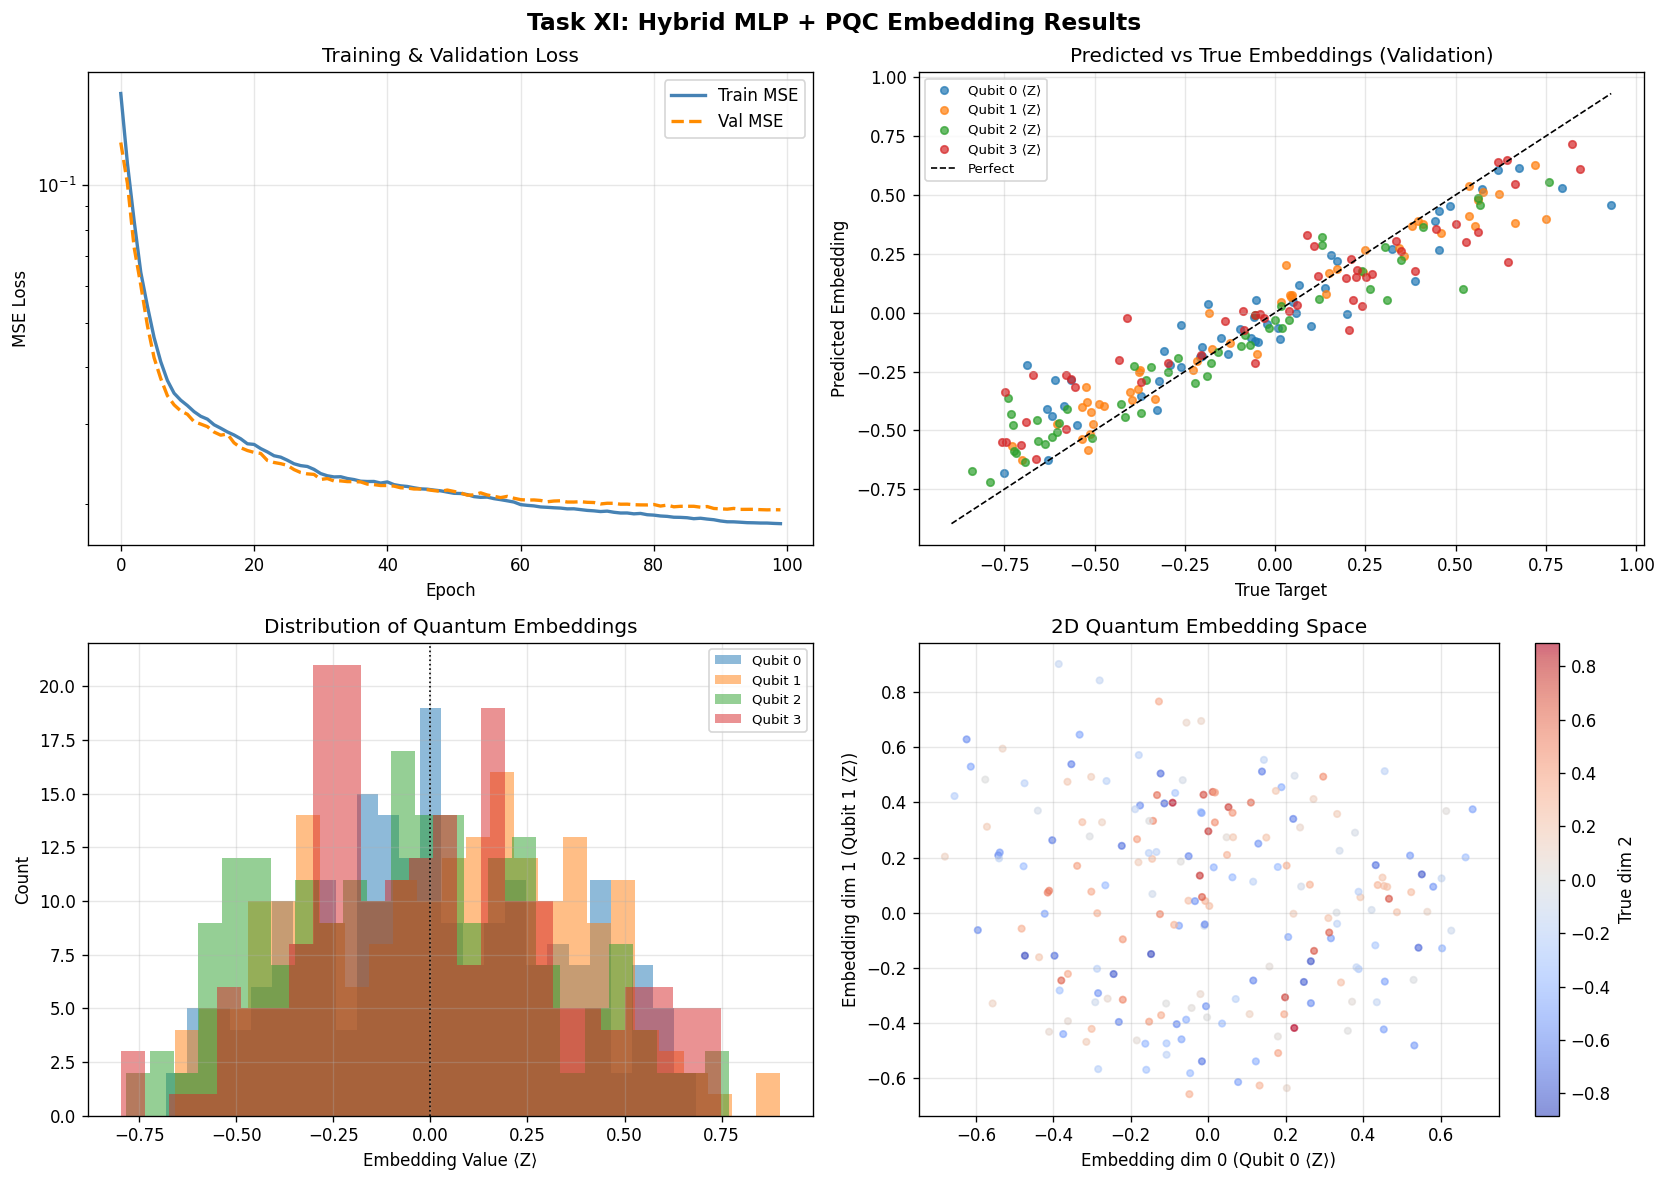

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))


ax = axes[0, 0]
ax.plot(train_losses, label='Train MSE', color='steelblue', lw=2)
ax.plot(val_losses,   label='Val MSE',   color='darkorange', lw=2, linestyle='--')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('Training & Validation Loss')
ax.legend()
ax.grid(alpha=0.3)
ax.set_yscale('log')


model.eval()
with torch.no_grad():
    pred_val = model(x_val).numpy()
true_val = y_val.numpy()

ax = axes[0, 1]
colors = plt.cm.tab10(np.arange(N_QUBITS))
for dim in range(N_QUBITS):
    ax.scatter(true_val[:50, dim], pred_val[:50, dim], s=20,
               alpha=0.7, color=colors[dim], label=f'Qubit {dim} ⟨Z⟩')
lo, hi = true_val.min(), true_val.max()
ax.plot([lo, hi], [lo, hi], 'k--', lw=1, label='Perfect')
ax.set_xlabel('True Target')
ax.set_ylabel('Predicted Embedding')
ax.set_title('Predicted vs True Embeddings (Validation)')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)


ax = axes[1, 0]
for dim in range(N_QUBITS):
    ax.hist(pred_val[:, dim], bins=25, alpha=0.5, color=colors[dim], label=f'Qubit {dim}')
ax.set_xlabel('Embedding Value ⟨Z⟩')
ax.set_ylabel('Count')
ax.set_title('Distribution of Quantum Embeddings')
ax.axvline(0, color='black', lw=1, linestyle=':')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)


ax = axes[1, 1]
sc = ax.scatter(pred_val[:, 0], pred_val[:, 1], c=true_val[:, 2],
                cmap='coolwarm', s=15, alpha=0.6)
plt.colorbar(sc, ax=ax, label='True dim 2')
ax.set_xlabel('Embedding dim 0 (Qubit 0 ⟨Z⟩)')
ax.set_ylabel('Embedding dim 1 (Qubit 1 ⟨Z⟩)')
ax.set_title('2D Quantum Embedding Space')
ax.grid(alpha=0.3)

plt.suptitle('Task XI: Hybrid MLP + PQC Embedding Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('task_xi_results.png', bbox_inches='tight')
plt.show()

In [11]:

from numpy import corrcoef

print('Per-dimension Pearson correlation (True vs Predicted):')
print('-' * 40)
for dim in range(N_QUBITS):
    r = corrcoef(true_val[:, dim], pred_val[:, dim])[0, 1]
    print(f'  Qubit {dim} ⟨Z⟩ correlation: {r:.4f}')

print(f'\nFinal Val MSE: {val_losses[-1]:.5f}')
print(f'Initial Val MSE: {val_losses[0]:.5f}')
print(f'Improvement: {(1 - val_losses[-1]/val_losses[0]) * 100:.1f}%')

Per-dimension Pearson correlation (True vs Predicted):
----------------------------------------
  Qubit 0 ⟨Z⟩ correlation: 0.9422
  Qubit 1 ⟨Z⟩ correlation: 0.9744
  Qubit 2 ⟨Z⟩ correlation: 0.9621
  Qubit 3 ⟨Z⟩ correlation: 0.9542

Final Val MSE: 0.01941
Initial Val MSE: 0.12421
Improvement: 84.4%


---
## 7. Circuit Parameter Analysis

/tmp/ipython-input-502/2747244582.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([sample_angles[:, i] for i in range(N_PQC_PARAMS)],


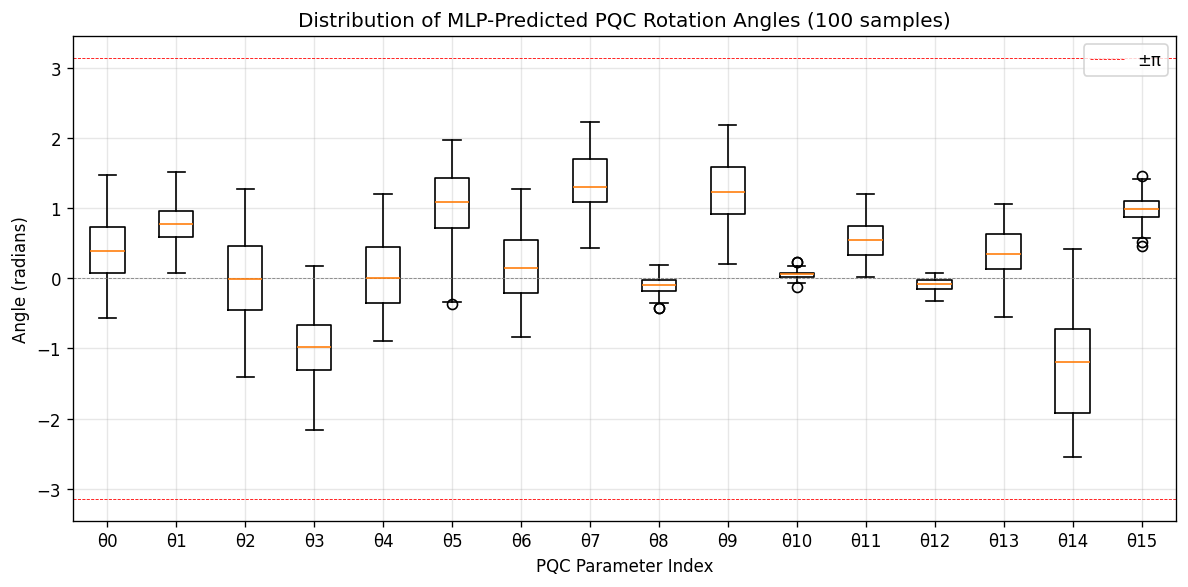

In [12]:

model.eval()
with torch.no_grad():
    sample_angles = model.mlp(data[:100]).numpy()

fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot([sample_angles[:, i] for i in range(N_PQC_PARAMS)],
           labels=[f'θ{i}' for i in range(N_PQC_PARAMS)])
ax.axhline(0, color='gray', lw=0.5, linestyle='--')
ax.axhline(np.pi, color='red', lw=0.5, linestyle='--', label='±π')
ax.axhline(-np.pi, color='red', lw=0.5, linestyle='--')
ax.set_xlabel('PQC Parameter Index')
ax.set_ylabel('Angle (radians)')
ax.set_title('Distribution of MLP-Predicted PQC Rotation Angles (100 samples)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('pqc_angles.png', bbox_inches='tight')
plt.show()